In [ ]:
# importing liraries
import pandas as pd
from sklearn.model_selection import  train_test_split , GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as Pipe_re
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier

In [ ]:
#loading the document
df=pd.read_csv('churn-bigml-80.csv')

In [107]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [108]:
df['Churn'].value_counts()

Churn
False    2278
True      388
Name: count, dtype: int64

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [110]:
df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [111]:
df.duplicated().sum()

0

In [112]:
df.describe(include=['int','float'])

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [113]:
df.shape

(2666, 20)

In [114]:
X=df.drop(columns='Churn')
y=df['Churn']

In [ ]:
# spliting the data for training and testing
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42,stratify=y)

In [ ]:
#seperating the numerical and categorical features
num_cols=X.select_dtypes(include='number').columns
obj_cols=X.select_dtypes(include='object').columns

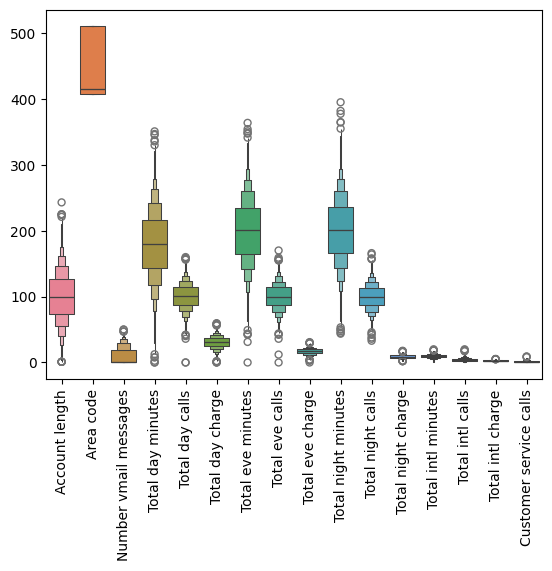

In [ ]:
# checking for outliers
sns.boxenplot(data=X[num_cols])
plt.xticks(rotation=90)
plt.show()

In [ ]:
# cheecking whether the target class labels are balanced or not
y.value_counts()

Churn
False    2278
True      388
Name: count, dtype: int64

In [121]:
y.value_counts(normalize=True)

Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64

In [122]:
preprocess=ColumnTransformer(
    transformers=[('Scaling',RobustScaler(),num_cols),
                  ('encoder',OneHotEncoder(handle_unknown='ignore'),obj_cols)
    ],
    remainder='passthrough'
    )

In [ ]:
#pipeline
main_pipe=Pipeline(
    steps=[('preprocess',preprocess),
           ('model',LogisticRegression(class_weight='balanced'))
           ]
)

In [ ]:
# parameter turning technique
grid_search=GridSearchCV(estimator=main_pipe,
                         param_grid = [
    {
        'model__solver': ['lbfgs'],
        'model__penalty': ['l2'],
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__max_iter': [100, 500, 1000]
    },
    {
        'model__solver': ['saga'],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__max_iter': [100, 500, 1000]
    }
])

In [125]:
grid_search.fit(Xtrain,ytrain)

C:\Users\ANUSHA C\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ANUSHA C\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ANUSHA C\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warni

,estimator,Pipeline(step...'balanced'))])
,param_grid,"[{'model__C': [0.01, 0.1, ...], 'model__max_iter': [100, 500, ...], 'model__penalty': ['l2'], 'model__solver': ['lbfgs']}, {'model__C': [0.01, 0.1, ...], 'model__max_iter': [100, 500, ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['saga']}]"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('Scaling', ...), ('encoder', ...)]"


In [126]:
grid_search.best_estimator_

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Scaling', ...), ('encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [127]:
grid_search.best_params_

{'model__C': 0.1,
 'model__max_iter': 100,
 'model__penalty': 'l2',
 'model__solver': 'lbfgs'}

In [128]:
ytrain_pred=grid_search.predict(Xtrain)
ytest_pred=grid_search.predict(Xtest)

In [153]:
from sklearn.metrics import classification_report, f1_score,accuracy_score

In [151]:
print('f1 score train :',f1_score(ytrain,ytrain_pred))
print('f1 score test :',f1_score(ytest,ytest_pred))

f1 score train : 0.5217391304347826
f1 score test : 0.4224137931034483


In [130]:
print(classification_report(ytrain,ytrain_pred))
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

       False       0.95      0.80      0.87      1822
        True       0.39      0.77      0.52       310

    accuracy                           0.79      2132
   macro avg       0.67      0.79      0.70      2132
weighted avg       0.87      0.79      0.82      2132

              precision    recall  f1-score   support

       False       0.92      0.77      0.84       456
        True       0.32      0.63      0.42        78

    accuracy                           0.75       534
   macro avg       0.62      0.70      0.63       534
weighted avg       0.84      0.75      0.78       534



`Logistic Regression` performed well on the training data but showed lower performance on the test data, especially for the minority class. Therefore, I decided to try another model to improve the classification performance.

In [131]:
preprocessor = ColumnTransformer( transformers=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'), obj_cols)
],
remainder='passthrough')

In [132]:
DT_pipe=Pipe_re(
    steps=[('encoder',preprocessor),
        ('under',RandomUnderSampler(random_state=42,sampling_strategy=0.2)),
           ('over',SMOTE()),
           ('tree',DecisionTreeClassifier(random_state=42))]
)

In [133]:
grid_search=GridSearchCV(estimator=DT_pipe,
                         param_grid={'tree__criterion':['gini', 'entropy'],
                                     'tree__splitter':['best', 'random'],
                                     'tree__max_depth': [1, 5, 10, 20, None]
                                     })

In [134]:
grid_search.fit(Xtrain,ytrain)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'tree__criterion': ['gini', 'entropy'], 'tree__max_depth': [1, 5, ...], 'tree__splitter': ['best', 'random']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('encoder', ...)]"


In [135]:
grid_search.best_estimator_

,steps,"[('encoder', ...), ('under', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [136]:
grid_search.best_params_

{'tree__criterion': 'entropy', 'tree__max_depth': 10, 'tree__splitter': 'best'}

In [147]:
#Temporary Evaluation for resampling technique.

encoded_X=preprocessor.fit_transform(Xtrain)

under=RandomUnderSampler(random_state=42,sampling_strategy=0.2)
X_sample,y_sample=under.fit_resample(encoded_X,ytrain)

print('undersampling: ')
print(y_sample.value_counts())

over=SMOTE(random_state=42)
X_over,y_over=over.fit_resample(X_sample,y_sample)

print("\n over Sampling: ")
print(y_over.value_counts())



undersampling: 
Churn
False    1550
True      310
Name: count, dtype: int64

 over Sampling: 
Churn
False    1550
True     1550
Name: count, dtype: int64


In [137]:
ytrain_DT=grid_search.predict(Xtrain)
ytest_DT=grid_search.predict(Xtest)

In [154]:
print('accuracy score train :',accuracy_score(ytrain,ytrain_DT))
print('accuracy score test :',accuracy_score(ytest,ytest_DT))

accuracy score train : 0.9803001876172608
accuracy score test : 0.9232209737827716


In [152]:
print('f1 score train :',f1_score(ytrain,ytrain_DT))
print('f1 score test :',f1_score(ytest,ytest_DT))

f1 score train : 0.9315960912052117
f1 score test : 0.7354838709677419


In [138]:
print(classification_report(ytrain,ytrain_DT))
print(classification_report(ytest,ytest_DT))

              precision    recall  f1-score   support

       False       0.99      0.99      0.99      1822
        True       0.94      0.92      0.93       310

    accuracy                           0.98      2132
   macro avg       0.96      0.96      0.96      2132
weighted avg       0.98      0.98      0.98      2132

              precision    recall  f1-score   support

       False       0.95      0.96      0.96       456
        True       0.74      0.73      0.74        78

    accuracy                           0.92       534
   macro avg       0.85      0.84      0.85       534
weighted avg       0.92      0.92      0.92       534



### Final Conclusion

Both `Logistic Regression` and `Decision Tree` were trained and evaluated for the churn prediction task. Logistic Regression showed **good training performance** but **lower performance on the test data**, particularly for the minority class. The `Decision Tree` achieved better overall test performance, but the difference between its training and test performance indicates some overfitting. Therefore, the Decision Tree performed better than Logistic Regression on the test set, but further tuning is required to improve its generalization and minority-class performance.
